In [1]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function
import pickle

In [6]:
filename = "./solutions/test6_crippa_uniformInfiltration_realparams_nophiclip.pkl"
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
Q = functionspace(domain, ("DG", 0))
W = functionspace(domain, ("CG", 1))
hw = Function(V)
phi = Function(Q)
T_i = Function(W)
T_w = Function(W)
p = Parameter(domain)

In [9]:
Se(-0.22, p.alpha.value, p.N.value)

np.float64(0.013969921832906356)

In [10]:
(4114/3514)/(1.3)

0.9005735300556017

In [7]:
interval = data_Annika["saving_interval"]
t_obs = [0, 10, 60, 120]
time = []
pressure_head = []
porosity = []
Ti = []
Tw = []
theta = []
z_line = np.linspace(P0[1], P3[1], nz)
x_data = P1[0]/2*np.ones_like(z_line)
grid = np.column_stack((x_data, z_line))
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
for i, t in enumerate(t_obs):
    time.append(data_Annika["times"][t])
    hw.x.array[:] = data_Annika["h_w"][t]
    phi.x.array[:] = data_Annika["phi"][t]
    T_i.x.array[:] = data_Annika["T_i"][t]
    T_w.x.array[:] = data_Annika["T_w"][t]
    pressure_head.append(eval_fct_on_grid(grid, hw, domain))
    porosity.append(eval_fct_on_grid(grid, phi, domain))
    Ti.append(eval_fct_on_grid(grid, T_i, domain))
    Tw.append(eval_fct_on_grid(grid, T_w, domain))
    h_c = pressure_head[i] * (pressure_head[i] < 0)
    theta.append(p.theta_r.value + (0.9*porosity[i] - p.theta_r.value)*Se(h_c, p.alpha.value, p.N.value))

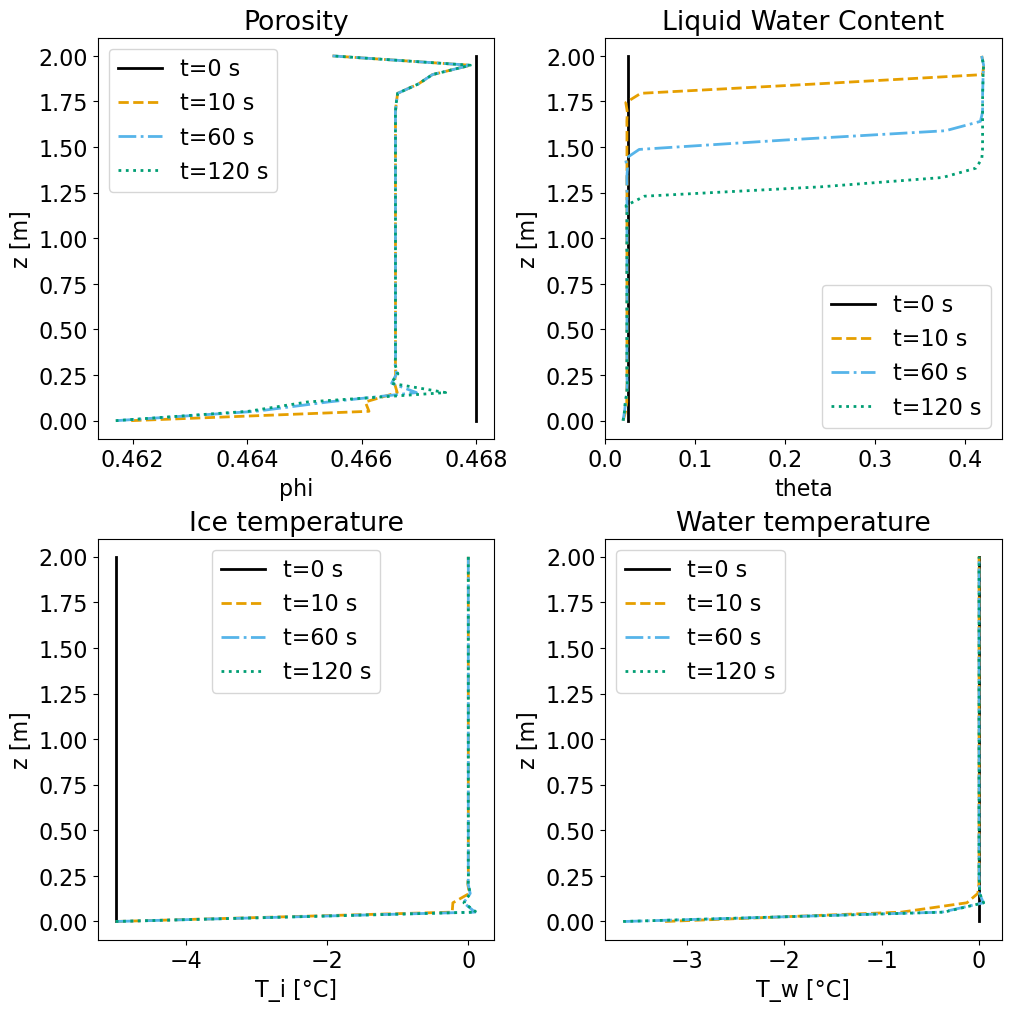

In [8]:
linestyles = ['-', '--', '-.', ':']  # solid, dashed, dash-dot, dotted
colors = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7'] # colour-blind friendly palette (Okabe-Ito)

plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'lines.linewidth': 2})
fig, ax = plt.subplots(2, 2, layout="constrained", figsize=(10, 10))

# Plot porosity for all times in the first subplot
for i in range(len(t_obs)):
    ls = linestyles[i % len(linestyles)]  # cycle through linestyles
    color = colors[i % len(colors)]       # cycle through colors (optional)
    ax[0, 0].plot(porosity[i], z_line, linestyle=ls, color=color, label=f't={t_obs[i]} s')
ax[0, 0].set_title('Porosity')
ax[0, 0].set_xlabel('phi')
ax[0, 0].set_ylabel('z [m]')
ax[0, 0].legend()

# Plot pressure_head for all times in the second subplot
for i in range(len(t_obs)):
    ls = linestyles[i % len(linestyles)]
    color = colors[i % len(colors)]
    ax[0, 1].plot(theta[i], z_line, linestyle=ls, color=color, label=f't={t_obs[i]} s')
ax[0, 1].set_title('Liquid Water Content')
ax[0, 1].set_xlabel('theta')
ax[0, 1].set_ylabel('z [m]')
ax[0, 1].legend()

# Plot Ti for all times in the third subplot
for i in range(len(t_obs)):
    ls = linestyles[i % len(linestyles)]
    color = colors[i % len(colors)]
    ax[1, 0].plot(Ti[i], z_line, linestyle=ls, color=color, label=f't={t_obs[i]} s')
ax[1, 0].set_title('Ice temperature')
ax[1, 0].set_xlabel('T_i [°C]')
ax[1, 0].set_ylabel('z [m]')
ax[1, 0].legend()

# Plot Tw for all times in the fourth subplot
for i in range(len(t_obs)):
    ls = linestyles[i % len(linestyles)]
    color = colors[i % len(colors)]
    ax[1, 1].plot(Tw[i], z_line, linestyle=ls, color=color, label=f't={t_obs[i]} s')
ax[1, 1].set_title('Water temperature')
ax[1, 1].set_xlabel('T_w [°C]')
ax[1, 1].set_ylabel('z [m]')
ax[1, 1].legend()

plt.show()